# Week 2 Assignment – Tesla Deliveries Forecasting (2015–2025)

Import all the Required Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


Part 1 : Loading and understanding the Dataset
This is the one of the most important process of any data science project. Before performing various operations on data such as cleaning , visualizing or building models we need to understand the data.

First step of any data science project is to load the required dataset. read_csv is function that reads a CSV(Comma separated values) file

head() is used to display first 5 rows of the dataset.

shape()tells us the size (number of rows and columns in the dataset)

info() shows null counts and data types

describe() is computes statistical Summary(such as mean, min, max,count etc)




In [23]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df = df.sort_values(['Year', 'Month']).reset_index(drop=True)
print("First 5 Rows of the Dataset:")
display(df.head())
print(f"Shape (rows × columns): {df.shape}")
print("Column Names:")
print(df.columns)
print("Dataset Information:")
df.info()
print("Statistical Summary of the dataset:")
display(df.describe())

First 5 Rows of the Dataset:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2015,1,Middle East,Model Y,10348,10835,85599.95,82,488,757.47,Estimated (Region),5991
1,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390
2,2015,1,Europe,Model Y,10835,11723,62939.81,120,718,1166.93,Official (Quarter),12301
3,2015,1,North America,Model X,8122,8343,62838.32,75,423,515.34,Official (Quarter),9297
4,2015,1,Middle East,Model S,13902,15423,94629.02,75,445,927.96,Official (Quarter),8666


Shape (rows × columns): (2640, 12)
Column Names:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='str')
Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   fl

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


Part 2:Data Cleaning: Missing values and Duplicate Rows

Data cleaning is again one of the most important process of data scinece project. In real world dataset the data is rarely perfect. It mostly contains missing values, duplicates or inconsistent data. Before performing any operation on the data it is very important to handle this issue.  


isnull().sum() gives the count NaN values per column

duplicated.sum() gives the count of duplicate row


In [24]:
print("Missing Values Per Column:")
print("─" * 40)
missing = df.isnull().sum()
print(f"Count : {missing}")
total_missing = missing.sum()
print(f"\nTotal Missing Cells: {total_missing}")
if total_missing == 0:
    print("No missing values found")
else:
    print(f"{total_missing} missing values need handling.")

print("─" * 40)

# Checking for duplicate rows
dup_count = df.duplicated().sum()
print(f"Duplicate Rows: {dup_count}")
if dup_count == 0:
    print("No duplicate rows found")
else: 
    print(f"Found {dup_count} duplicate rows.")

Missing Values Per Column:
────────────────────────────────────────
Count : Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Total Missing Cells: 0
No missing values found
────────────────────────────────────────
Duplicate Rows: 0
No duplicate rows found


Part 3: Exploratory Data Analysis (EDA)

It is the process of understanding the dataset with the help of visualization(different types of graph and visuals) and statistics before building any model.

Without visualization, it is difficult to identify trends or patterns.

In this section we are supposed to create 5 Charts:
1. **Deliveries by Car Model** — which Tesla model sells the most?
2. **Deliveries by Region** — which region has most no of deliveries
3. **Correlation Heatmap** — which features relate to each other?
4. **Production vs Deliveries Scatter** — shows the numerical relationship between production and deliveries.
5. **Time-Trend Line Chart** — how has Tesla grown year-over-year?



✅ Production_Units ↔ Estimated_Deliveries correlation: 0.9942


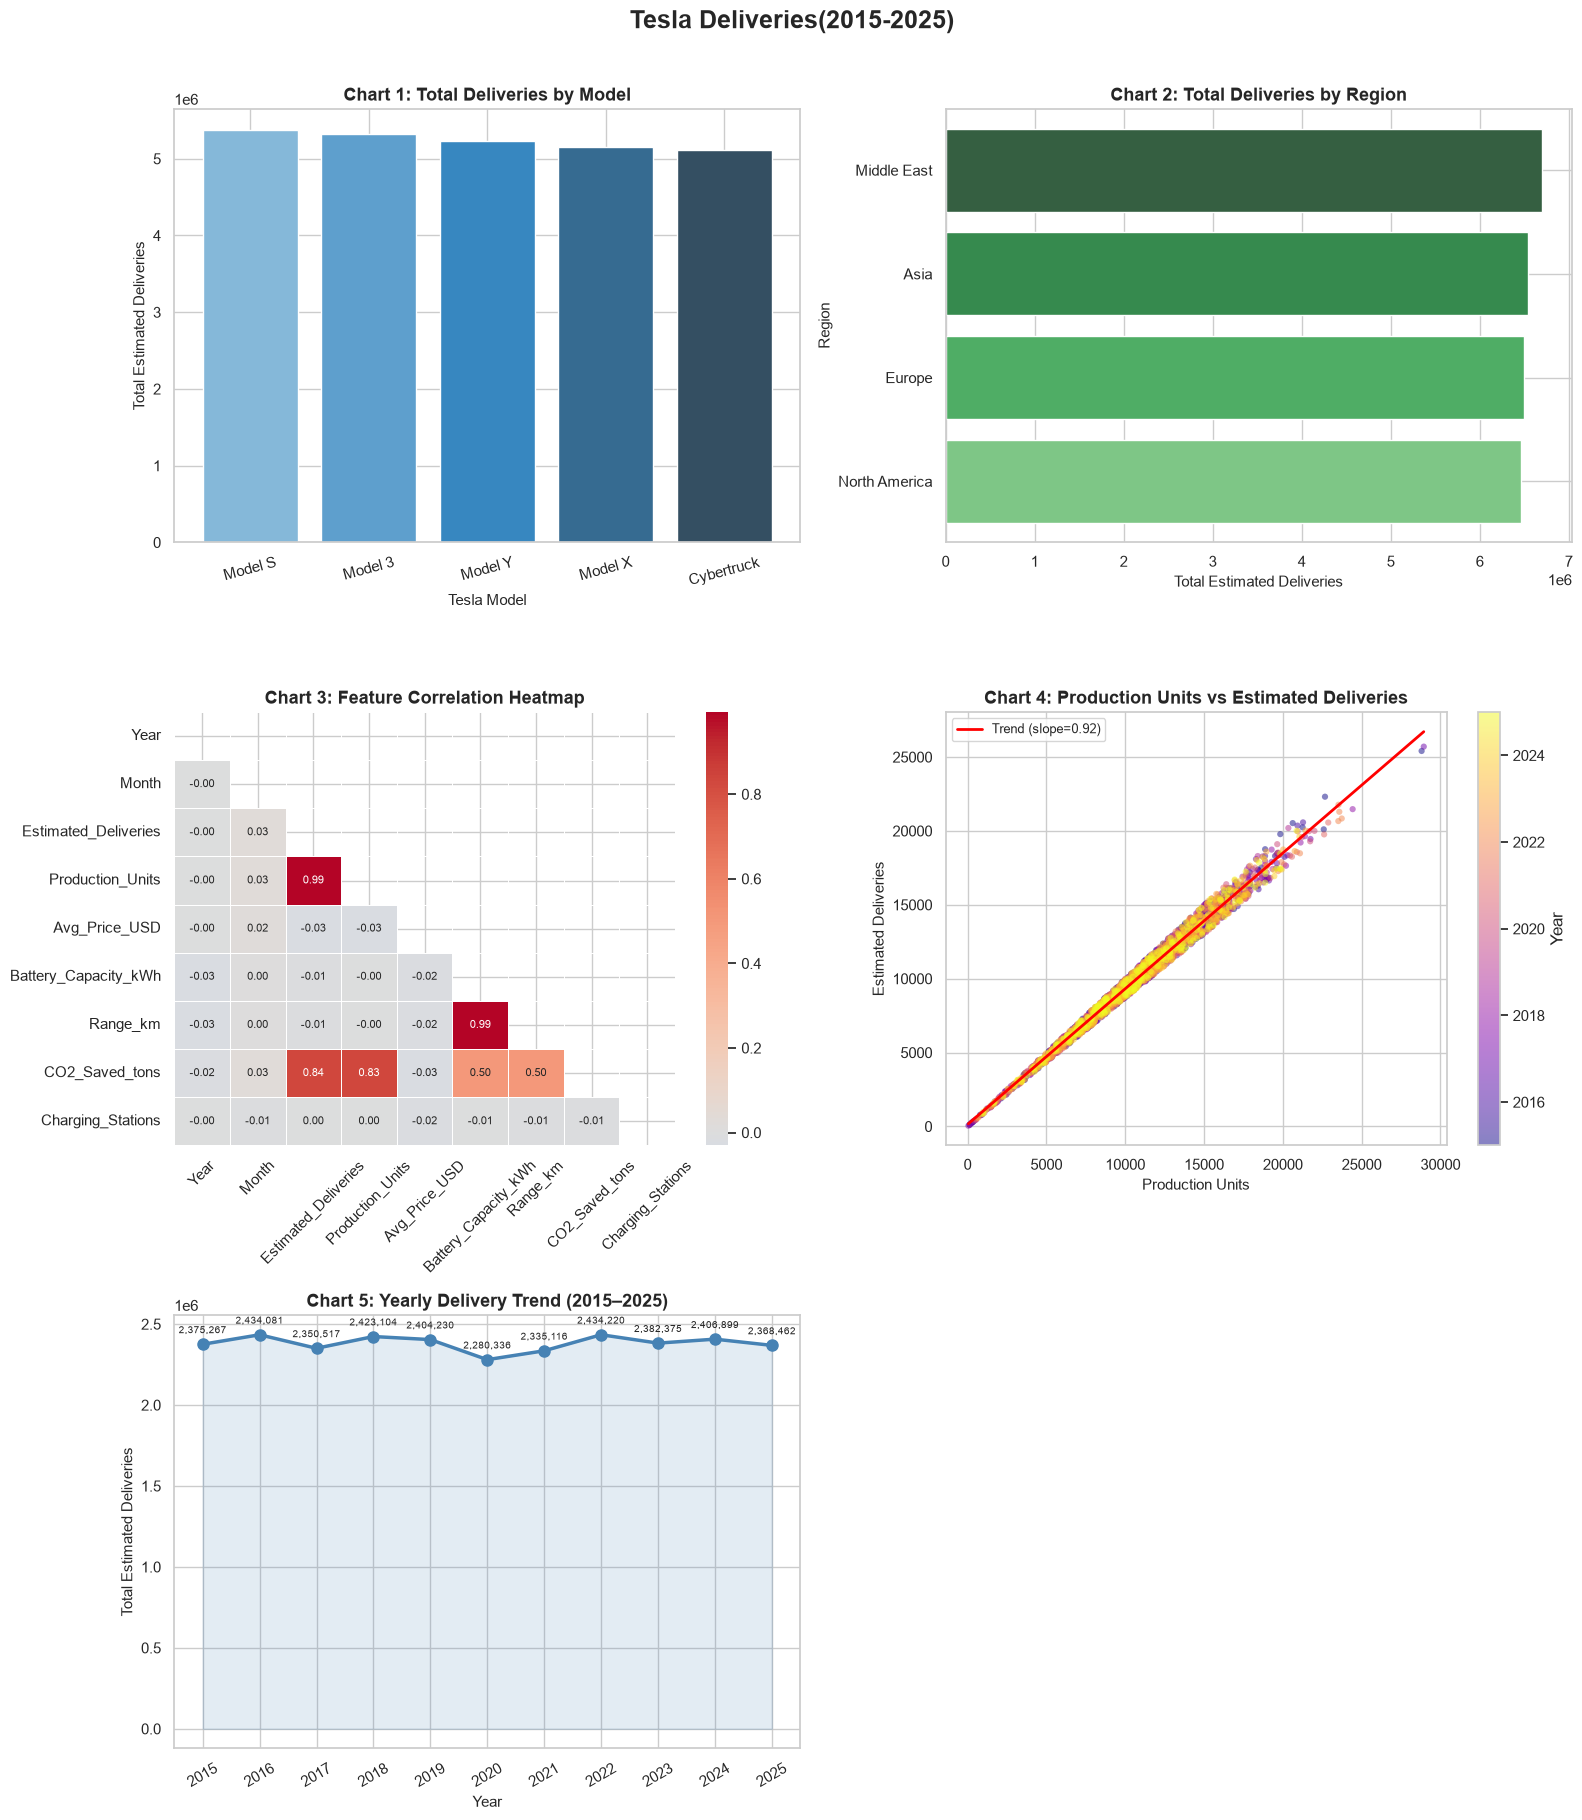


 All 5 EDA charts rendered successfully.


In [25]:
sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Tesla Deliveries(2015-2025)', fontsize=18, fontweight='bold', y=1.01)

#Chart 1: Total Deliveries by Model(Bar Chart)
# which Tesla model sells the most.

ax1 = axes[0, 0]
model_deliveries = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)
bars = ax1.bar(model_deliveries.index, model_deliveries.values,
               color=sns.color_palette('Blues_d', len(model_deliveries)))
ax1.set_title('Chart 1: Total Deliveries by Model', fontsize=13, fontweight='bold')
ax1.set_xlabel('Tesla Model', fontsize=11)
ax1.set_ylabel('Total Estimated Deliveries', fontsize=11)
ax1.tick_params(axis='x', rotation=15)

# CHART 2:Total Deliveries by Region (Horizontal Bar)
# which regions have the highest sales?

ax2 = axes[0, 1]
region_deliveries = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values()
colors = sns.color_palette('Greens_d', len(region_deliveries))
h_bars = ax2.barh(region_deliveries.index, region_deliveries.values, color=colors)
ax2.set_title('Chart 2: Total Deliveries by Region', fontsize=13, fontweight='bold')
ax2.set_xlabel('Total Estimated Deliveries', fontsize=11)
ax2.set_ylabel('Region', fontsize=11)

# CHART 3:Correlation Heatmap
#Correlation measures how strongly two variables move together
ax3 = axes[1, 0]
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask for cleaner view
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, ax=ax3, linewidths=0.5,
            annot_kws={'size': 8})
ax3.set_title('Chart 3: Feature Correlation Heatmap', fontsize=13, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.tick_params(axis='y', rotation=0)
prod_deliv_corr = corr_matrix.loc['Production_Units', 'Estimated_Deliveries']
print(f"✅ Production_Units ↔ Estimated_Deliveries correlation: {prod_deliv_corr:.4f}")

# CHART 4:Production vs Deliveries Scatter
#A scatter plot shows the relationship between two continuous numeric variables.

ax4 = axes[1, 1]
scatter = ax4.scatter(df['Production_Units'], df['Estimated_Deliveries'],
                      c=df['Year'], cmap='plasma', alpha=0.5, s=20, edgecolors='none')

m, b = np.polyfit(df['Production_Units'], df['Estimated_Deliveries'], 1)
x_line = np.linspace(df['Production_Units'].min(), df['Production_Units'].max(), 100)
ax4.plot(x_line, m*x_line + b, color='red', linewidth=2, label=f'Trend (slope={m:.2f})')
plt.colorbar(scatter, ax=ax4, label='Year')
ax4.set_title('Chart 4: Production Units vs Estimated Deliveries', fontsize=13, fontweight='bold')
ax4.set_xlabel('Production Units', fontsize=11)
ax4.set_ylabel('Estimated Deliveries', fontsize=11)
ax4.legend(fontsize=9)

# CHART 5:Time-Trend Line Chart
#Show trends over time


ax5 = axes[2, 0]
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()
ax5.plot(yearly['Year'], yearly['Estimated_Deliveries'],
         marker='o', linewidth=2.5, color='steelblue', markersize=8, label='Total Deliveries')
ax5.fill_between(yearly['Year'], yearly['Estimated_Deliveries'],
                 alpha=0.15, color='steelblue')
ax5.set_title('Chart 5: Yearly Delivery Trend (2015–2025)', fontsize=13, fontweight='bold')
ax5.set_xlabel('Year', fontsize=11)
ax5.set_ylabel('Total Estimated Deliveries', fontsize=11)
ax5.xaxis.set_major_locator(plt.MultipleLocator(1))
ax5.tick_params(axis='x', rotation=30)
for _, row in yearly.iterrows():
    ax5.annotate(f"{row['Estimated_Deliveries']:,.0f}",
                 (row['Year'], row['Estimated_Deliveries']),
                 textcoords="offset points", xytext=(0, 8), ha='center', fontsize=7.5)


#Hide unused subplot
axes[2, 1].set_visible(False)

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n All 5 EDA charts rendered successfully.")




Part 4: Feature Engineering

Feature enginnering is the process of creating or transforming the features so that a ml model can learn patterns more efficeintly.


Sometimes the original dataset isn't enough, Creating meaningful new features helps the model detect trends and relationships more accurately.


Why?

The models can only understand the numerical data , they cannot undertand the textual data.


In this section, categorical variables (`Region`, `Model`, and `Source_Type`) are converted into numerical values using LabelEncoder.


Additionally, two time-based features are created: 

1,`Deliveries_Lag1: which captures the previous delivery value.

2.`Rolling_Mean_3`: which calculates the average of the current and previous two observations.


Also the missing values introduced during feature engineering process were replaced with mean values.


In [26]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Region"] = le.fit_transform(df["Region"])
df["Model"] = le.fit_transform(df["Model"])
df["Source_Type"] = le.fit_transform(df["Source_Type"])

# ── Lag Feature: Deliveries_Lag1 ──────────────────────────────────────────────
df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)
# First row is NaN since there's no "previous" → fill with column mean
lag_mean = df['Deliveries_Lag1'].mean()
df['Deliveries_Lag1'] = df['Deliveries_Lag1'].fillna(lag_mean)

# ── Rolling Mean Feature: Rolling_Mean_3 ──────────────────────────────────────
df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(window=3, min_periods=1).mean()
df['Rolling_Mean_3'] = df['Rolling_Mean_3'].fillna(df['Rolling_Mean_3'].mean())

print(f"DataFrame shape after feature engineering: {df.shape}")

DataFrame shape after feature engineering: (2640, 14)


Part 5:Chronological Train-Test Split and Linear Regression

Train/Test Split :

Before training Any ML Model we divide the data into 2 Parts:

Training Data :Model learns patterns from this data.

Test Data :Model is evaluated on unseen data.

Why Chronological Split (NOT train_test_split)?

In random split the model is randomly trained and tested on a random dataset.

For example the data is from 2015 to 2025. so in random split the model maybe trained on data form 2022 and tested on 2019, in this case the model sees the future during traing.


Chronological Split:In this type of split the model trains on the past data and predicts the future data and maintains a chronological order.

In any time-series problem, chronological split is used.


Linear Regression:

linear regression is the simplest model.

it assumes a linear relationship between the features and the target and tries to find the best straight line between them.


Linear Regression Performance
-----------------------------------
MAE (Mean Absolute Error)      : 317.94
RMSE (Root Mean Squared Error)     : 386.70
R² Score (Coefficient of Determination) : 0.9889
 R² ≥ 0.95 — Requirement Met


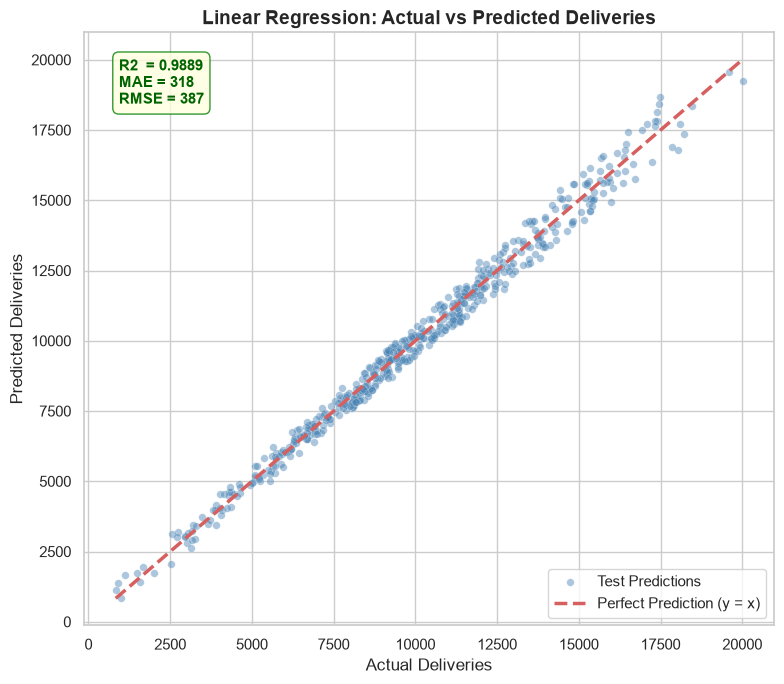

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define features and target variable
X = df.drop(columns=["Estimated_Deliveries"])
y = df["Estimated_Deliveries"]

# ── Chronological 80/20 Split ─────────────────────────────────────────────────
split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ── Train Linear Regression Model───────────────────────────────────────────────────
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predictions
y_pred_lr = linear_model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("-" * 35)
print(f"MAE (Mean Absolute Error)      : {mae:.2f}")
print(f"RMSE (Root Mean Squared Error)     : {rmse:.2f}")
print(f"R² Score (Coefficient of Determination) : {r2:.4f}")

if r2 >= 0.95:
    print(f" R² ≥ 0.95 — Requirement Met")

#Actual vs Predicted
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(y_test, y_pred_lr, alpha=0.45, color='steelblue', s=30,
           edgecolors='white', linewidth=0.3, label='Test Predictions')

lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
ax.plot(lims, lims, 'r--', linewidth=2.5, label='Perfect Prediction (y = x)')

ax.set_title('Linear Regression: Actual vs Predicted Deliveries', fontsize=14, fontweight='bold')
ax.set_xlabel('Actual Deliveries', fontsize=12)
ax.set_ylabel('Predicted Deliveries', fontsize=12)
ax.legend(fontsize=11)

stats_text = 'R2  = {:.4f}\nMAE = {:,.0f}\nRMSE = {:,.0f}'.format(r2, mae, rmse)
ax.text(0.05, 0.88, stats_text, transform=ax.transAxes,
        fontsize=11, color='darkgreen', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='green', alpha=0.8))

plt.tight_layout()
plt.savefig('lr_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

Part 6: 5-Fold Cross Validation
In 5-Fold Cross Validation the dataset is divided into 5 eqaul parts unline train-test split in which the dataset is divided into 80-20 parts.


The model is trained on 4 folds and tested on the 5th. This is repeated 5 times and then the mean or average of the 5 is taken under consideration.

A single train/test split can be lucky or unlucky depending on the split of the dataset.

R² tells us how much of the variation in deliveries is explained by the model.



Per-fold R²: Tell How well the model performed on each individual fold.

Mean R²: is much more reliable than a single train-test split.

Std Dev:How stable the model is — lower is better




In [28]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=False)
cv_scores = cross_val_score(LinearRegression(), X_train, y_train,
                             cv=kf, scoring='r2')

print("5-Fold Cross Validation – Linear Regression")
print("─" * 45)
for i, score in enumerate(cv_scores, 1):
    bar = '█' * int(score * 30)
    print(f"  Fold {i}: R² = {score:.4f}  {bar}")

print("─" * 45)
print(f"  Mean R²  : {cv_scores.mean():.4f}")
print(f"  Std Dev  : {cv_scores.std():.4f}  ← lower = more stable model")

5-Fold Cross Validation – Linear Regression
─────────────────────────────────────────────
  Fold 1: R² = 0.9895  █████████████████████████████
  Fold 2: R² = 0.9911  █████████████████████████████
  Fold 3: R² = 0.9903  █████████████████████████████
  Fold 4: R² = 0.9915  █████████████████████████████
  Fold 5: R² = 0.9908  █████████████████████████████
─────────────────────────────────────────────
  Mean R²  : 0.9906
  Std Dev  : 0.0007  ← lower = more stable model


Part 7:GridSearchCV and Random Forest Regressor

Why Random Forest?

Linear Regression assumes a straight-line relationship between features and target.

whereas Random Forest builds hundreds of Decision Trees and averages their predictions


Thatswhy random forest regressor generallay performs higher than linear regression.

It's much more powerful for complex real-world data.


Hyperparameters:


Parameter:
Parameters = values the model learns automatically from data.

Hyperparameter:

A hyperparameter is a setting that you choose before training the model.

GridSearchCV:

Rather than guessing hyperparameters,GridSearchCV systematically tries every combination of :


n_estimators: number of trees (more = better but slower)

max_depth: how deep each tree can grow.



Fitting 3 folds for each of 6 candidates, totalling 18 fits

 Best Parameters : {'max_depth': None, 'n_estimators': 100}
   Best CV R²     : 0.9887

Random Forest Performance
-----------------------------------
MAE      : 334.43
RMSE     : 411.50
R² Score : 0.9874
  R² ≥ 0.98 — Requirement Met


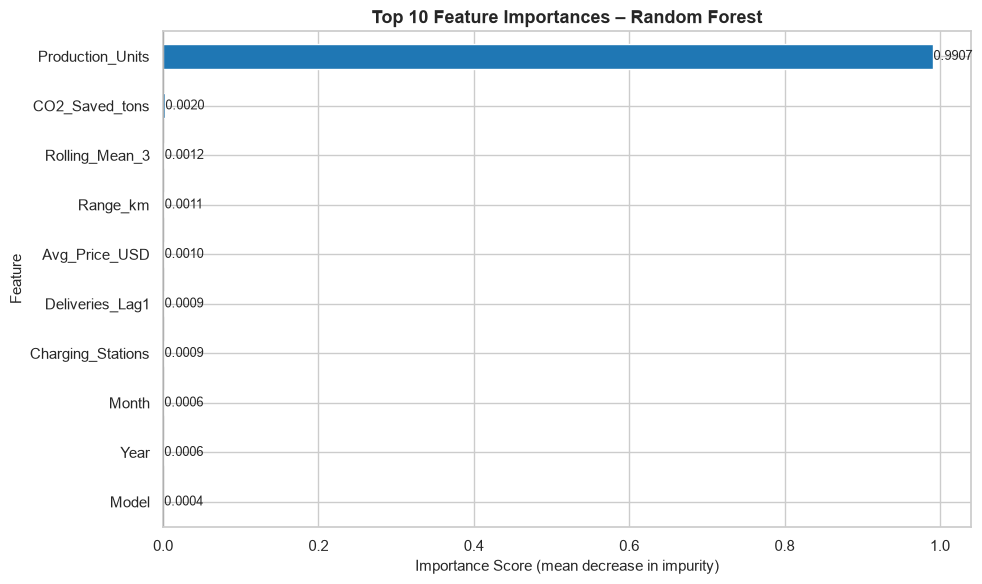


Top Feature: Production_Units (0.9907)


In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# ── Hyperparameter Grid ───────────────────────────────────────────────────────
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Train Grid Search
grid_search.fit(X_train, y_train)

# ── Results ───────────────────────────────────────────────────────────────────
print(f"\n Best Parameters : {grid_search.best_params_}")
print(f"   Best CV R²     : {grid_search.best_score_:.4f}")

# ── Training Best Model ───────────────────────────────────────────────────
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf )
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Performance")
print("-" * 35)
print(f"MAE      : {rf_mae:.2f}")
print(f"RMSE     : {rf_rmse:.2f}")
print(f"R² Score : {rf_r2:.4f}")
if rf_r2 >= 0.98:
    print(f"  R² ≥ 0.98 — Requirement Met")

importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top10 = importances.nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d62728' if i == top10.index[-1] else '#1f77b4' for i in range(len(top10))]
top10.plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title('Top 10 Feature Importances – Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score (mean decrease in impurity)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.axvline(0, color='black')
for i, (val, name) in enumerate(zip(top10.values, top10.index)):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop Feature: {importances.idxmax()} ({importances.max():.4f})")

Part 8:ADF Stationarity Test

What is Stationarity?

A time series is stationary if its statistical properties (mean, variance, autocorrelation) do NOT change over time.

Time series models like ARIMA requires stationarity to work accurately.


Augmented Dickey-Fuller (ADF) Test:

The ADF Test checks whether a time series is stationary. It is done by performing a test to check for unit root.

the presence of unit root indicates that it is NON-stationary.


Hypotheses:

H₀ (Null Hypothesis)        : Series HAS a unit root → NON-STATIONARY

H₁ (Alternative Hypothesis) : Series does NOT have a unit root → STATIONARY


Decision rule:  

- p-value < 0.05 → Reject H₀ → Series IS stationary 

- p-value ≥ 0.05 → Fail to Reject H₀ → Series is NON-stationary


In [30]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(df['Estimated_Deliveries'], autolag='AIC') 

adf_stat  = adf_result[0]
p_value   = adf_result[1]
n_lags    = adf_result[2]
n_obs     = adf_result[3]


print("Augmented Dickey-Fuller Stationarity Test")
print("=" * 50)
print(f"  ADF Statistic     : {adf_stat:.4f}")
print(f"  p-value           : {p_value:.6f}")
print(f"  Lags Used         : {n_lags}")
print(f"  Observations Used : {n_obs}")

print("INTERPRETATION:")
print("=" * 50)

if p_value < 0.05:
    print(f"  p-value = {p_value:.4f} < 0.05")
    print("  REJECT H₀ (unit root hypothesis)")
    print("  Conclusion: Series IS STATIONARY")
    print("  Safe to use ARIMA or other stationary-assuming models.")
else:
    print(f" p-value = {p_value:.4f} ≥ 0.05")
    print("  FAIL TO REJECT H₀")
    print("  Conclusion: Series is NON-STATIONARY")
    print("  Apply differencing before ARIMA.")

Augmented Dickey-Fuller Stationarity Test
  ADF Statistic     : -24.6621
  p-value           : 0.000000
  Lags Used         : 4
  Observations Used : 2635
INTERPRETATION:
  p-value = 0.0000 < 0.05
  REJECT H₀ (unit root hypothesis)
  Conclusion: Series IS STATIONARY
  Safe to use ARIMA or other stationary-assuming models.


Part 9:Forecast Table + Model Comparison


Forecating means predicting the future.

Forecast Table:

A forecast table is structured , row by row comparison of what model predicted and the actual result.

A forecast table shows exactly where each model was right and where it was wrong.

Percentage error:Percentage Error measures how far the predicted value is from the actual value, expressed as a percentage of the actual value.

Instead of just telling us the difference, it tells us how large the error is relative to the true value.

Model Comparison table :

A final table which is used to compare linear regression and random forest across all three MAE,RMSE and R².


In [31]:
forecast_df = pd.DataFrame({
    'Actual':          y_test.values[:20],
    'LR_Predicted':    y_pred_lr[:20].round(0).astype(int),
    'RF_Predicted':    y_pred_rf[:20].round(0).astype(int),
}).reset_index(drop=True)
forecast_df.index = forecast_df.index + 1 

forecast_df['LR_Error_%']  = ((forecast_df['Actual'] - forecast_df['LR_Predicted']).abs()
                               / forecast_df['Actual'] * 100).round(2)
forecast_df['RF_Error_%']  = ((forecast_df['Actual'] - forecast_df['RF_Predicted']).abs()
                               / forecast_df['Actual'] * 100).round(2)

print("Forecast Table – First 20 Test Records")
print("=" * 75)
print(forecast_df.to_string())
print("=" * 75)
print(f"Average LR Error %: {forecast_df['LR_Error_%'].mean():.2f}%")
print(f"Average RF Error %: {forecast_df['RF_Error_%'].mean():.2f}%")

# Model Comparison
comparison_table = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R² Score": [r2, rf_r2]
})

print("\n\nModel Comparison Table")
print(comparison_table.to_string(index=False))
print(f"\nWinner: {'Random Forest' if rf_r2 > r2 else 'Linear Regression'} "
      f"(higher R² = better explanatory power)")




Forecast Table – First 20 Test Records
    Actual  LR_Predicted  RF_Predicted  LR_Error_%  RF_Error_%
1     9476          9064          8969        4.35        5.35
2     8179          8448          8442        3.29        3.22
3    14430         15096         15250        4.62        5.68
4    15912         16211         15906        1.88        0.04
5    15077         14598         14770        3.18        2.04
6    11280         11384         11278        0.92        0.02
7     4070          3964          4109        2.60        0.96
8    11636         11572         11567        0.55        0.59
9    12540         12515         12289        0.20        2.00
10   12717         11842         11762        6.88        7.51
11    5365          5813          5726        8.35        6.73
12   11323         11603         11809        2.47        4.29
13    8624          9026          8891        4.66        3.10
14   11986         11621         11691        3.05        2.46
15   10577      

Conclusion:
In this notebook we loaded , cleaned and explored the tesla deliveries datasets, created new features such as lag
and rolling-mean ,  trained and compared linear regression model against a random forest model using a chronological train test split.The ADF test confirmed the deliveries series is stationary ,the time series models such as ARIMA can be used safely.